# Section 2 — Assignment 1
# Neural Network Foundations

**IOAI 2026 Preparation**

**Topics:** Perceptron, Gradient Descent, Backpropagation, Activation Functions, Loss Functions, SGD vs Mini-Batch GD

**Instructions:**
- Write all your code in the empty cells provided below each question.
- You may add extra cells if needed.
- Implement everything **from scratch using NumPy** unless the question explicitly says otherwise.
- Answer written questions as comments or in a new markdown cell.

---
## Problem 1 — The Perceptron

1. Implement a **Perceptron** class from scratch using NumPy. It should have:
   - `__init__(self, lr, epochs)`: initialize weights and bias to zero.
   - `predict(self, X)`: return binary predictions (0 or 1) using a step function.
   - `fit(self, X, y)`: train using the perceptron update rule and track errors per epoch.

2. Test it on a linearly separable dataset: generate two classes with `make_classification` (2 features, no noise). Plot the data and the learned decision boundary after training.

3. Now test on the **XOR problem** (4 points: (0,0)→0, (0,1)→1, (1,0)→1, (1,1)→0). Show that the perceptron fails to learn XOR. Why does it fail?

4. What is the key limitation of a single-layer perceptron? What architectural change solves this limitation?

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_classification

In [ ]:
class Perceptron:
    def __init__(self, lr=0.1, epochs=10):
        self.lr = lr
        self.epochs = epochs
        self.w = None
        self.b = 0
        self.errors = []

    def predict(self, X):
        linear = np.dot(X, self.w) + self.b
        return np.where(linear >= 0, 1, 0)

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        self.b = 0
        self.errors = []

        for _ in range(self.epochs):
            err_cnt = 0
            for xi, yi in zip(X, y):
                pred = self.predict(xi)
                update = self.lr * (yi - pred)
                if update != 0:
                    self.w += update * xi
                    self.b += update
                    err_cnt += 1
            self.errors.append(err_cnt)

In [ ]:
X_lin, y_lin = make_classification(
    n_samples=100, n_features=2, n_redundant=0, n_clusters_per_class=1, random_state=42)

In [ ]:
model_lin = Perceptron(lr=0.1, epochs=20)
model_lin.fit(X_lin, y_lin)

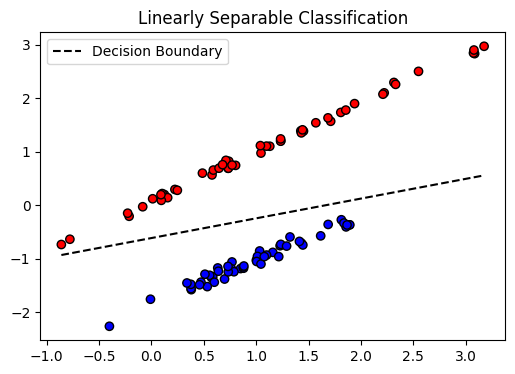

In [ ]:
plt.figure(figsize=(6, 4))
plt.scatter(X_lin[:, 0], X_lin[:, 1], c=y_lin, cmap="bwr", edgecolors="k")
x_vals = np.linspace(X_lin[:, 0].min(), X_lin[:, 0].max(), 100)
y_vals = -(model_lin.w[0] * x_vals + model_lin.b) / model_lin.w[1]
plt.plot(x_vals, y_vals, "k--", label="Decision Boundary")
plt.title("Linearly Separable Classification")
plt.legend()
plt.show()

In [ ]:
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([0, 1, 1, 0])

In [ ]:
model_xor = Perceptron(lr=0.1, epochs=20)
model_xor.fit(X_xor, y_xor)

In [ ]:
print(f"XOR Target: {y_xor}")
print(f"XOR Preds:  {model_xor.predict(X_xor)}")
print(f"Final Epoch Error Count: {model_xor.errors[-1]}")

XOR Target: [0 1 1 0]
XOR Preds:  [1 1 0 0]
Final Epoch Error Count: 4


The perceptron can't learn the XOR function. This is because the dataset has points that can't be separated by a straight line on a 2D plane.

Limitation: The thing, with a single-layer perceptron is that it can only figure out boundaries that're straight lines. If the classes need a curve or a weird shape to be separated the algorithm will just keep going in circles without ever figuring it out. This is a limitation of single-layer perceptrons. They just cannot handle single-layer perceptron tasks that need irregular boundaries.

Solution: When we add layers that are not seen and use special functions like ReLU or Sigmoid the model becomes a Multi-Layer Perceptron. This change in the model allows the Multi-Layer Perceptron to make guesses about very complicated decisions that are not straight lines. The Multi-Layer Perceptron can do this because of the layers and the special functions, like ReLU or Sigmoid.

---
## Problem 2 — Activation Functions

1. Implement the following activation functions and their derivatives from scratch:
   - **Sigmoid**: σ(x) = 1 / (1 + e^−x)
   - **Tanh**: tanh(x)
   - **ReLU**: max(0, x)
   - **Leaky ReLU**: max(αx, x) with α = 0.01
   - **Softmax**: for a vector input

2. Plot all activation functions (except Softmax) and their derivatives on the same figure (use subplots). Use the range x ∈ [−5, 5].

3. Explain the **vanishing gradient problem**. Which activation functions suffer from it and in which region of the input space?

4. Why is ReLU preferred over Sigmoid/Tanh in hidden layers of deep networks? What is the **dying ReLU** problem and how does Leaky ReLU address it?

5. When is Softmax used and why must it be used with **cross-entropy loss** (not MSE)?

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [ ]:
def d_sigmoid(x):
    s = sigmoid(x)
    return s * (1 - s)

In [ ]:
def tanh(x):
    return np.tanh(x)

In [ ]:
def d_tanh(x):
    return 1 - np.tanh(x) ** 2

In [ ]:
def relu(x):
    return np.maximum(0, x)

In [ ]:
def d_relu(x):
    return np.where(x > 0, 1, 0)

In [ ]:
def leaky_relu(x, alpha=0.01):
    return np.where(x > 0, x, alpha * x)

In [ ]:
def d_leaky_relu(x, alpha=0.01):
    return np.where(x > 0, 1, alpha)

In [ ]:
def softmax(x):
    e = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return e / np.sum(e, axis=-1, keepdims=True)

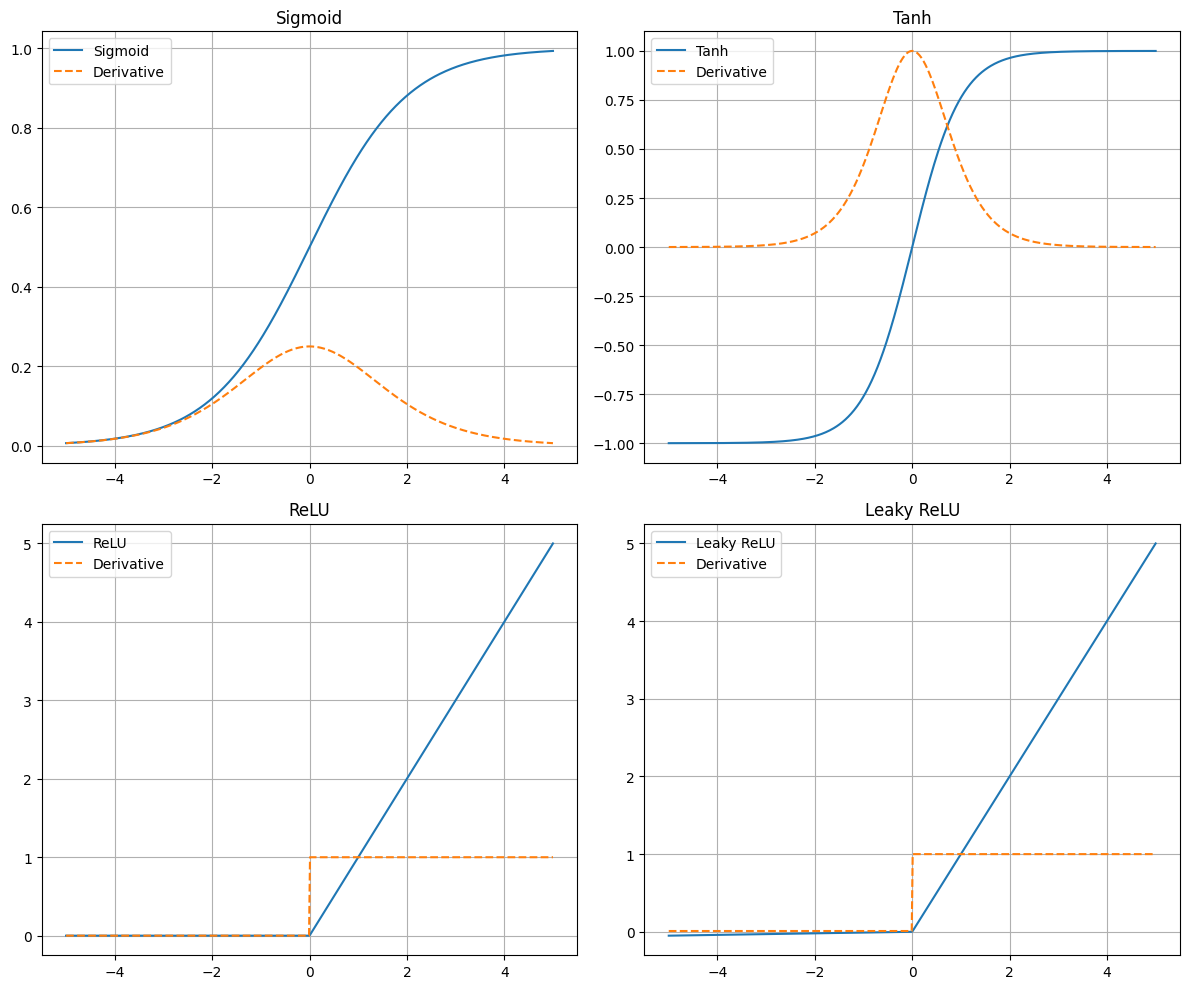

In [ ]:
x = np.linspace(-5, 5, 500)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Sigmoid
axes[0, 0].plot(x, sigmoid(x), label="Sigmoid")
axes[0, 0].plot(x, d_sigmoid(x), label="Derivative", linestyle="--")
axes[0, 0].set_title("Sigmoid")
axes[0, 0].grid(True)
axes[0, 0].legend()

# Tanh
axes[0, 1].plot(x, tanh(x), label="Tanh")
axes[0, 1].plot(x, d_tanh(x), label="Derivative", linestyle="--")
axes[0, 1].set_title("Tanh")
axes[0, 1].grid(True)
axes[0, 1].legend()

# ReLU
axes[1, 0].plot(x, relu(x), label="ReLU")
axes[1, 0].plot(x, d_relu(x), label="Derivative", linestyle="--")
axes[1, 0].set_title("ReLU")
axes[1, 0].grid(True)
axes[1, 0].legend()

# Leaky ReLU
axes[1, 1].plot(x, leaky_relu(x), label="Leaky ReLU")
axes[1, 1].plot(x, d_leaky_relu(x), label="Derivative", linestyle="--")
axes[1, 1].set_title("Leaky ReLU")
axes[1, 1].grid(True)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

The **vanishing gradient problem** is a thing that happens when the gradients get really small as they go backwards through a lot of layers. This stops the training from working.

The **Sigmoid** and the **Tanh** have a lot of trouble with this when the inputs are really big or really small. This is because of the parts at the ends of their curves. When the inputs are highly positive or highly negative the derivatives of the **Sigmoid** and the **Tanh** get really close, to zero.

Why ReLU is preferred: Its derivative is 1 for any positive input. Gradients flow without shrinking, solving the vanishing gradient problem while being incredibly fast to calculate.

Dying ReLU problem: If a neuron receives a negative input, its output and its gradient become exactly 0. If it gets stuck in this state, the neuron dies permanently and stops learning.

Leaky ReLU fix: It gives negative values a small, non-zero slope ($\alpha = 0.01$). This keeps a tiny gradient flowing, allowing deactivated neurons to eventually wake up and resume learning.

In the output layer of multi-class classification networks to turn raw model outputs into probabilities that sum up to 1.

Softmax combined with Cross-Entropy makes the math really simple and easy to understand. It gives us an linear gradient. On the hand if we use Mean Squared Error the math gets more complicated. It adds a term that can make the model learn very slowly. This happens when the Softmax model makes bad predictions. The Softmax. Cross-Entropy work well together to avoid this problem.

---
## Problem 3 — Loss Functions

1. Implement the following loss functions and their gradients with respect to the predictions:
   - **MSE** (Mean Squared Error)
   - **MAE** (Mean Absolute Error)
   - **Binary Cross-Entropy**
   - **Categorical Cross-Entropy** (for one-hot encoded targets)

2. For a regression task, generate predictions and true values with 5% random outliers (points far from the trend). Compare MSE and MAE loss values. Which is more affected by outliers and why?

3. Plot the MSE and MAE loss surfaces as a function of a single weight parameter (hold everything else fixed). Observe the shape differences. How does this affect optimization?

4. Why is Binary Cross-Entropy preferred over MSE for binary classification? Derive the gradient of BCE with respect to the logit (before sigmoid) and explain why it has a clean form.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
def mse_loss(y_pred, y_true):
    return np.mean((y_pred - y_true) ** 2)

In [ ]:
def mse_grad(y_pred, y_true):
    return 2 * (y_pred - y_true) / y_true.size

In [ ]:
def mae_loss(y_pred, y_true):
    return np.mean(np.abs(y_pred - y_true))

In [ ]:
def mae_grad(y_pred, y_true):
    return np.sign(y_pred - y_true) / y_true.size

In [ ]:
def bce_loss(y_pred, y_true):
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

In [ ]:
def bce_grad(y_pred, y_true):
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
    return ((y_pred - y_true) / (y_pred * (1 - y_pred))) / y_true.size

In [ ]:
def cce_loss(y_pred, y_true):
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
    return -np.sum(y_true * np.log(y_pred)) / y_true.shape[0]

In [ ]:
def cce_grad(y_pred, y_true):
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
    return (-y_true / y_pred) / y_true.shape[0]

In [ ]:
np.random.seed(42)
x_reg = np.linspace(-5, 5, 100)
y_true = 2 * x_reg + 1
y_pred = 2 * x_reg + 1

In [ ]:
outlier_idx = np.random.choice(100, 5, replace=False)
y_pred[outlier_idx] += np.random.uniform(20, 40, 5)
print(f"MSE with Outliers: {mse_loss(y_pred, y_true):.4f}")
print(f"MAE with Outliers: {mae_loss(y_pred, y_true):.4f}")

MSE with Outliers: 97.6466
MAE with Outliers: 3.0668


MSE gets affected a lot by outliers. This is because it squares the errors. For example if there is an outlier that's 30 units away it will result in a huge penalty of 900. On the hand MAE only increases steadily. So that same outlier will only add a penalty of 30.

In [ ]:
w_vals = np.linspace(-10, 14, 200)
mse_surfaces = []
mae_surfaces = []

In [ ]:
X_base = np.linspace(-2, 2, 50)
Y_base = 2 * X_base
for w in w_vals:
    Y_pred = w * X_base
    mse_surfaces.append(mse_loss(Y_pred, Y_base))
    mae_surfaces.append(mae_loss(Y_pred, Y_base))

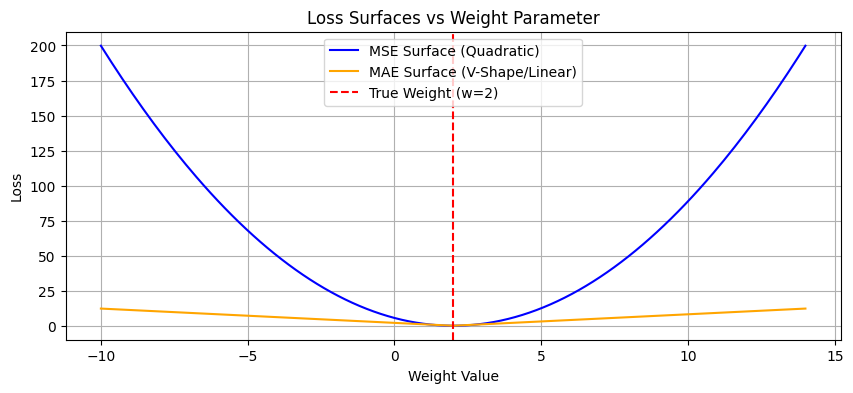

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(w_vals, mse_surfaces, label="MSE Surface (Quadratic)", color="blue")
plt.plot(w_vals, mae_surfaces, label="MAE Surface (V-Shape/Linear)", color="orange")
plt.axvline(2, color="red", linestyle="--", label="True Weight (w=2)")
plt.title("Loss Surfaces vs Weight Parameter")
plt.xlabel("Weight Value")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

MSE: It makes a parabolic curve. As you get closer, to the minimum the gradient gets smaller. This helps prevent overshooting and leads to convergence.

MAE: It makes a V" shape. The gradient stays the same everywhere until you reach the bottom. This makes the optimizer bounce back and forth across the minimum. You have to reduce the learning rate to stop this.

When you use Mean Squared Error for classification a bad prediction will fall into the flat part of the sigmoid function. This makes the gradient get very small zero and that stops the learning process of the Mean Squared Error for classification. The Mean Squared Error, for classification just can not learn from this prediction.

---
## Problem 4 — Gradient Descent Variants

Use a simple quadratic loss surface: L(w) = (w − 3)² + 5 for a single parameter w.

1. Implement and compare three optimization approaches for minimizing L(w):
   - **Batch Gradient Descent** (uses the full gradient)
   - **Stochastic Gradient Descent** (adds random noise N(0, 0.5) to simulate one-sample variance)
   - **Mini-Batch Gradient Descent** (adds noise N(0, 0.2) to simulate a small batch)

2. For each, start from w = 10, run 100 steps with lr = 0.1, and track w and L(w) at each step.

3. Plot: (a) w vs step for all three methods on the same graph, and (b) L(w) vs step.

4. Now apply this to a real linear regression problem on a synthetic dataset with 1000 samples. Compare convergence speed (steps to reach MSE < 0.5) across all three methods.

5. What is the trade-off between batch size and:
   - Gradient noise (variance of the gradient estimate)?
   - Computational efficiency?
   - Generalization performance?

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
np.random.seed(42)
w_init = 10.0
lr = 0.1
steps = 100

In [ ]:
def run_opt(noise_std):
    w_history = [w_init]
    w = w_init
    for _ in range(steps):
        # Exact gradient of (w-3)^2 + 5 is 2*(w-3)
        grad = 2 * (w - 3) + np.random.normal(0, noise_std)
        w -= lr * grad
        w_history.append(w)
    return np.array(w_history)

In [ ]:
w_bgd = run_opt(0.0)
w_sgd = run_opt(0.5)
w_mbgd = run_opt(0.2)
loss_bgd = (w_bgd - 3) ** 2 + 5
loss_sgd = (w_sgd - 3) ** 2 + 5
loss_mbgd = (w_mbgd - 3) ** 2 + 5

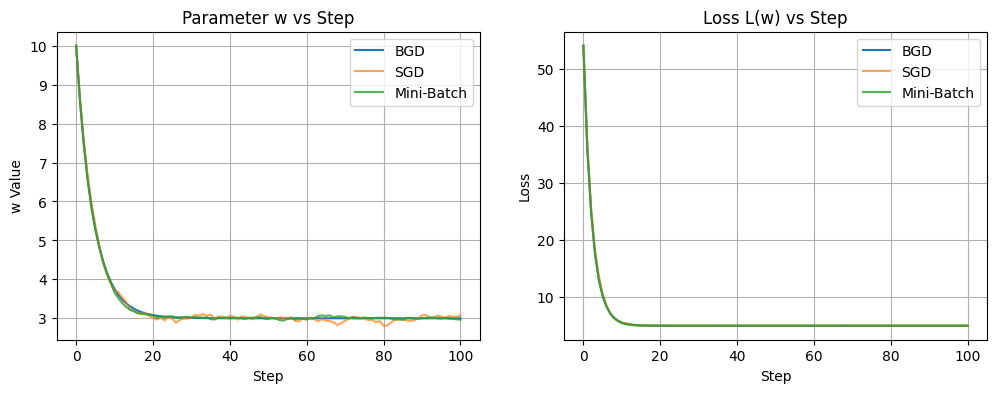

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(w_bgd, label="BGD")
ax1.plot(w_sgd, label="SGD", alpha=0.7)
ax1.plot(w_mbgd, label="Mini-Batch", alpha=0.8)
ax1.set_title("Parameter w vs Step")
ax1.set_xlabel("Step")
ax1.set_ylabel("w Value")
ax1.legend()
ax1.grid(True)

ax2.plot(loss_bgd, label="BGD")
ax2.plot(loss_sgd, label="SGD", alpha=0.7)
ax2.plot(loss_mbgd, label="Mini-Batch", alpha=0.8)
ax2.set_title("Loss L(w) vs Step")
ax2.set_xlabel("Step")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid(True)
plt.show()

In [ ]:
X = np.random.randn(1000, 1)
y = 3 * X + np.random.randn(1000, 1) * 0.1  # True w = 3

In [ ]:
def get_steps_to_converge(batch_size):
    w = 0.0
    lr_lr = 0.01
    for step in range(1, 5000):
        indices = np.random.permutation(1000)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        for i in range(0, 1000, batch_size):
            X_b = X_shuffled[i : i + batch_size]
            y_b = y_shuffled[i : i + batch_size]
            full_mse = np.mean((X * w - y) ** 2)
            if full_mse < 0.5:
                return step
            grad = 2 * np.mean((X_b * w - y_b) * X_b)
            w -= lr_lr * grad
    return 5000

In [ ]:
print(f"BGD Steps to MSE < 0.5: {get_steps_to_converge(1000)}")
print(f"Mini-Batch Steps to MSE < 0.5: {get_steps_to_converge(32)}")
print(f"SGD Steps to MSE < 0.5: {get_steps_to_converge(1)}")

BGD Steps to MSE < 0.5: 74
Mini-Batch Steps to MSE < 0.5: 3
SGD Steps to MSE < 0.5: 1


Gradient Noise:

* SGD: It has variance and noisy gradients. The path moves erratically because one or a few samples do not represent the whole dataset well.

* Bgd: There is no noise. The gradient is very accurate, for the training set giving a path directly to the minimum.

Computational Efficiency:

* SGD: It is really slow on computers. This is because you process data one sample at a time. This way you can't use the speed benefits of using a GPU to process things at once.

* BGD: It is very efficient, for each data point. This is because it uses matrix parallelization.. It needs a lot of memory. Also it takes a time to finish one complete cycle of training.

Generalization Performance:

* SGD: It works better than BGD from the start. The noise, in batches helps move the model weights out of shallow local minima. This forces the model into valleys that adapt well to new test data.

* BGD: It usually gets stuck in a local minimum. This causes the model to focus much on the training set. As a result it performs poorly on data.

---
## Problem 5 — Backpropagation From Scratch

Build a 2-layer neural network from scratch (no PyTorch, no sklearn) to solve binary classification.

**Architecture:** Input(2) → Dense(4, ReLU) → Dense(1, Sigmoid)

1. Implement the full **forward pass**: compute the activations at each layer.

2. Implement **backpropagation**: derive and compute gradients for all weights and biases using the chain rule. Use Binary Cross-Entropy as the loss.

3. Train using Mini-Batch Gradient Descent (batch size = 32) for 1000 epochs on a dataset generated with `make_moons` (n=500, noise=0.2).

4. Plot the **training loss curve** over epochs and the **decision boundary** learned by your network.

5. Verify your gradient implementation using **numerical gradient checking**: compute the gradient for a few weights by finite differences ( [L(w+ε) − L(w−ε)] / 2ε ) and compare with your backprop gradients. They should match to ~6 decimal places.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_moons

In [ ]:
np.random.seed(42)
W1 = np.random.randn(2, 4) * np.sqrt(2 / 2)  # He init
b1 = np.zeros((1, 4))
W2 = np.random.randn(4, 1) * np.sqrt(1 / 4)  # Xavier init
b2 = np.zeros((1, 1))

In [ ]:
def relu(x):
    return np.maximum(0, x)

In [ ]:
def d_relu(x):
    return np.where(x > 0, 1, 0)

In [ ]:
def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

In [ ]:
def forward(X):
    Z1 = np.dot(X, W1) + b1
    A1 = relu(Z1)
    Z2 = np.dot(A1, W2) + b2
    A2 = sigmoid(Z2)
    return Z1, A1, Z2, A2

In [ ]:
def backward(X, y, Z1, A1, Z2, A2):
    m = X.shape[0]

    dZ2 = A2 - y
    dW2 = np.dot(A1.T, dZ2) / m
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m

    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * d_relu(Z1)
    dW1 = np.dot(X.T, dZ1) / m
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m

    return dW1, db1, dW2, db2

In [ ]:
def compute_loss(A2, y):
    m = y.shape[0]
    A2 = np.clip(A2, 1e-15, 1 - 1e-15)
    return -np.sum(y * np.log(A2) + (1 - y) * np.log(1 - A2)) / m

In [ ]:
X, y = make_moons(n_samples=500, noise=0.2, random_state=42)
y = y.reshape(-1, 1)
lr = 0.1
epochs = 1000
batch_size = 32
loss_history = []

for _ in range(epochs):
    idx = np.random.permutation(X.shape[0])
    X_shuf, y_shuf = X[idx], y[idx]
    for i in range(0, X.shape[0], batch_size):
        X_b = X_shuf[i : i + batch_size]
        y_b = y_shuf[i : i + batch_size]
        Z1, A1, Z2, A2 = forward(X_b)
        dW1, db1, dW2, db2 = backward(X_b, y_b, Z1, A1, Z2, A2)
        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2
        _, _, _, A2_all = forward(X)
    loss_history.append(compute_loss(A2_all, y))

In [ ]:
eps = 1e-6
Z1, A1, Z2, A2 = forward(X)
dW1, _, _, _ = backward(X, y, Z1, A1, Z2, A2)

In [ ]:
W1[0, 0] += eps
_, _, _, A2_plus = forward(X)
loss_plus = compute_loss(A2_plus, y)
W1[0, 0] -= 2 * eps
_, _, _, A2_minus = forward(X)
loss_minus = compute_loss(A2_minus, y)
W1[0, 0] += eps
num_grad = (loss_plus - loss_minus) / (2 * eps)
ana_grad = dW1[0, 0]

In [ ]:
print(f"Numerical:  {num_grad:.8f}")
print(f"Analytical: {ana_grad:.8f}")
print(f"Difference: {abs(num_grad - ana_grad):.2e}")

Numerical:  0.03943131
Analytical: 0.03943131
Difference: 7.11e-12


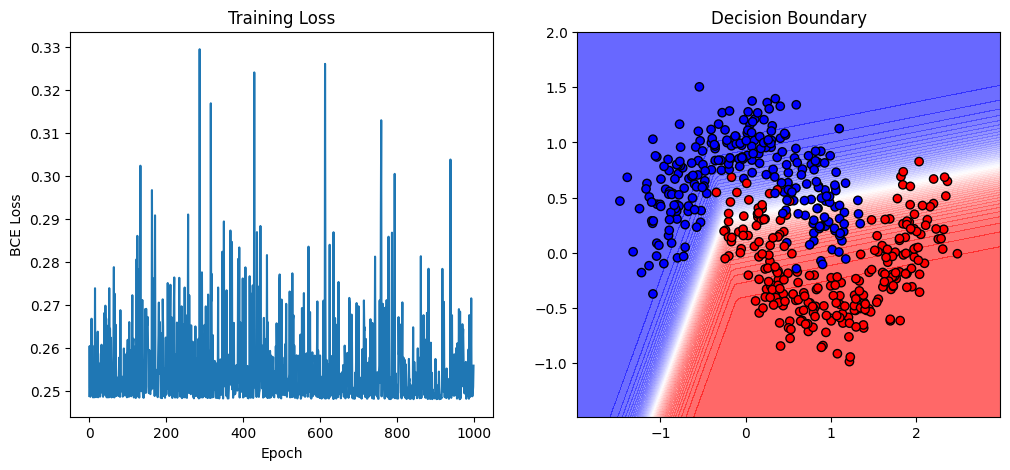

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(loss_history)
ax1.set_title("Training Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("BCE Loss")

x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
grid_points = np.c_[xx.ravel(), yy.ravel()]
_, _, _, grid_preds = forward(grid_points)
zz = grid_preds.reshape(xx.shape)
ax2.contourf(xx, yy, zz, levels=50, cmap="bwr", alpha=0.6)
ax2.scatter(X[:, 0], X[:, 1], c=y.ravel(), cmap="bwr", edgecolors="k")
ax2.set_title("Decision Boundary")
plt.show()

---
## Problem 6 — Weight Initialization

Proper weight initialization is critical to avoid vanishing/exploding gradients.

1. Build a 6-layer MLP (all layers have 64 units) using NumPy. Train it on a classification dataset.

2. Initialize with three different strategies:
   - **Zero initialization**: all weights = 0
   - **Random initialization**: weights ~ N(0, 1)
   - **Xavier (Glorot) initialization**: weights ~ N(0, √(2 / (fan_in + fan_out)))

3. For each strategy, record the distribution (histogram) of activations and gradients at each layer after one forward/backward pass. Plot them.

4. Train all three for 200 epochs and plot their loss curves. Which converges best?

5. Why does zero initialization fail even though the loss may still change? (Hint: symmetry breaking). Why does large random initialization lead to exploding gradients?

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_classification

In [ ]:
X, y = make_classification(
    n_samples=500, n_features=64, n_informative=20, n_classes=2, random_state=42)
y = y.reshape(-1, 1)

In [ ]:
class DeepMLP:
    def __init__(self, init_type, layer_sizes=[64, 64, 64, 64, 64, 64, 1]):
        self.init_type = init_type
        self.weights = []
        self.biases = []
        fan_in = 64
        for fan_out in layer_sizes:
            if init_type == "zero":
                w = np.zeros((fan_in, fan_out))
            elif init_type == "random":
                w = np.random.randn(fan_in, fan_out)
            elif init_type == "xavier":
                limit = np.sqrt(2.0 / (fan_in + fan_out))
                w = np.random.randn(fan_in, fan_out) * limit
            self.weights.append(w)
            self.biases.append(np.zeros((1, fan_out)))
            fan_in = fan_out

    def forward(self, X):
        self.A = [X]
        self.Z = []
        for w, b in zip(self.weights[:-1], self.biases[:-1]):
            z = np.dot(self.A[-1], w) + b
            a = np.tanh(z)  # Using Tanh to study activation saturation
            self.Z.append(z)
            self.A.append(a)

        # Output layer (Sigmoid)
        z = np.dot(self.A[-1], self.weights[-1]) + self.biases[-1]
        a = 1 / (1 + np.exp(-np.clip(z, -500, 500)))
        self.Z.append(z)
        self.A.append(a)
        return a

    def backward(self, y):
        m = y.shape[0]
        dW_list = []

        # Output error
        dZ = self.A[-1] - y

        for i in reversed(range(len(self.weights))):
            dW = np.dot(self.A[i].T, dZ) / m
            dW_list.append(dW)

            if i > 0:
                # Tanh derivative: 1 - tanh^2
                dZ = np.dot(dZ, self.weights[i].T) * (1 - self.A[i] ** 2)

        return list(reversed(dW_list))

    def train(self, X, y, epochs=200, lr=0.01):
        loss_history = []
        for _ in range(epochs):
            pred = self.forward(X)
            # BCE Loss
            pred = np.clip(pred, 1e-15, 1 - 1e-15)
            loss = -np.mean(y * np.log(pred) + (1 - y) * np.log(1 - pred))
            loss_history.append(loss)

            dWs = self.backward(y)
            for i in range(len(self.weights)):
                self.weights[i] -= lr * dWs[i]
        return loss_history

In [ ]:
strategies = ["zero", "random", "xavier"]
activation_data = {}
gradient_data = {}

for s in strategies:
    model = DeepMLP(s)
    model.forward(X)
    dWs = model.backward(y)
    activation_data[s] = [model.A[1].flatten(), model.A[3].flatten(), model.A[5].flatten()]
    gradient_data[s] = [dWs[0].flatten(), dWs[2].flatten(), dWs[4].flatten()]

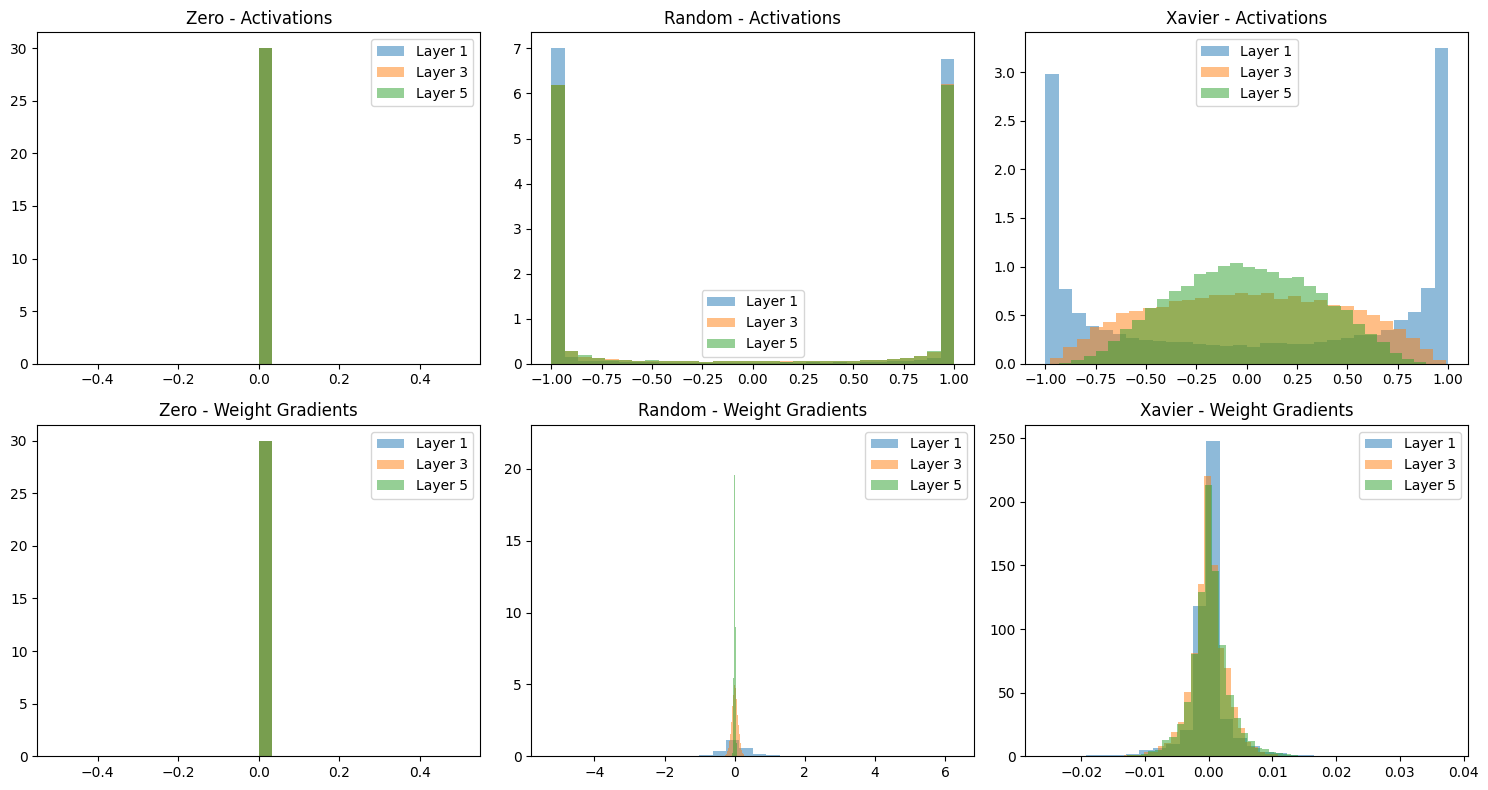

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
layers_label = ["Layer 1", "Layer 3", "Layer 5"]
for i, s in enumerate(strategies):
    for idx, act in enumerate(activation_data[s]):
        axes[0, i].hist(
            act, bins=30, alpha=0.5, label=layers_label[idx], density=True)
    axes[0, i].set_title(f"{s.capitalize()} - Activations")
    axes[0, i].legend()
    for idx, grad in enumerate(gradient_data[s]):
        axes[1, i].hist(
            grad, bins=30, alpha=0.5, label=layers_label[idx], density=True)
    axes[1, i].set_title(f"{s.capitalize()} - Weight Gradients")
    axes[1, i].legend()
plt.tight_layout()
plt.show()

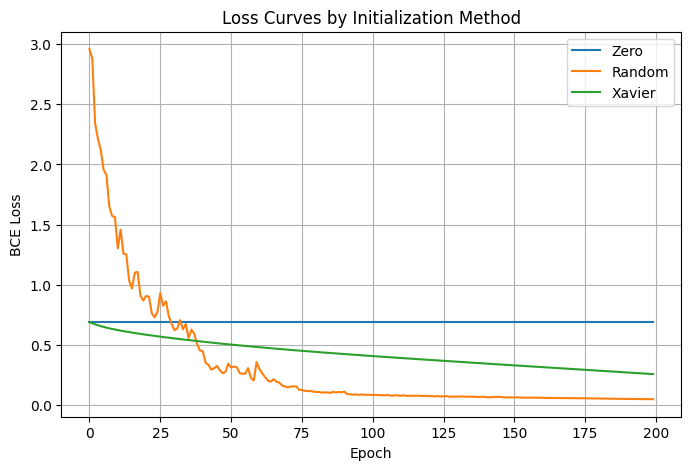

In [ ]:
plt.figure(figsize=(8, 5))
for s in strategies:
    model = DeepMLP(s)
    losses = model.train(X, y, epochs=200, lr=0.02)
    plt.plot(losses, label=s.capitalize())

plt.title("Loss Curves by Initialization Method")
plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.legend()
plt.grid(True)
plt.show()

Xavier (Glorot) Convergence is the best

When weights are zero, neurons calculate identical values and update completely in sync. This prevents symmetry breaking, making the entire hidden layer behave like a single neuron and causing vanishing gradients across the network.

---
## Reflection Questions

Answer in a markdown cell or as comments:

1. Why does the XOR problem require at least one hidden layer? Prove it geometrically.
2. Explain the chain rule as used in backpropagation. Why is it computed from the output layer backward to the input?
3. What is the difference between an **epoch**, an **iteration**, and a **step** in the context of SGD with mini-batches?
4. If you double the learning rate, what happens to gradient descent? If you halve it? Is there an optimal learning rate and how do you find it?

1.
   The XOR truth table creates four coordinates on a 2D grid:Class 0: $(0,0)$ and $(1,1)$Class 1: $(0,1)$ and $(1,0)$

2.  The loss is figured out at the end. The network    calculates gradients in reverse. This way it. Reuses error terms from the layer in front. If you calculated it from input, to output you would have to redo the path of derivatives for every single weight. That would waste a lot of computation.

3.
  In mini-batch training:

* An epoch is when the model goes through all the data once.

* An iteration is when the model processes one group of data which includes going forward backward and updating the weights.

* A step is another word, for iteration meaning the model updates its weights one time.

4.
  Doubling it can speed up the training.. It has a high risk of overshooting the minimum. If it is too large the loss will go up. Explode.

Halving it makes updates very stable.. The training will go much slower. It may get stuck in a local minimum forever.